# grivan newman algorithm

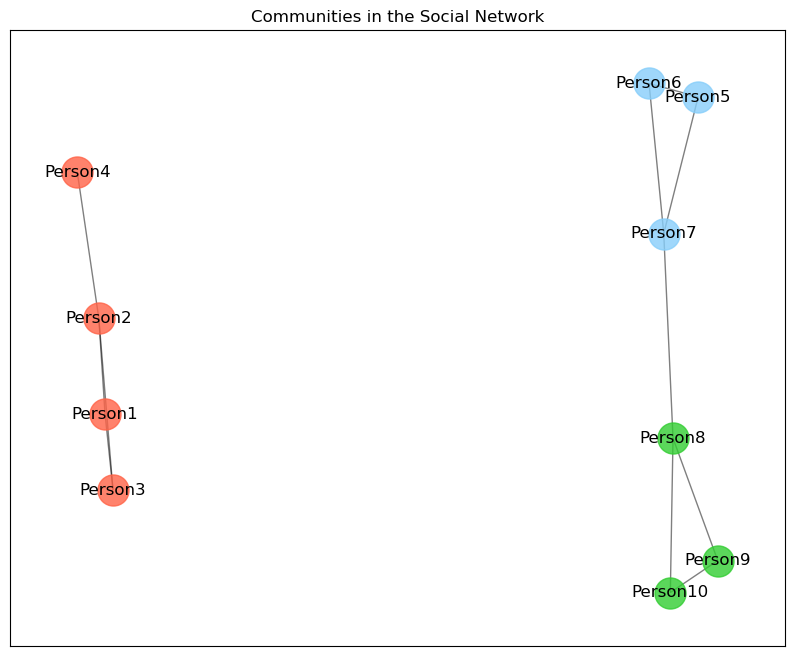

Communities detected by the Girvan-Newman algorithm:
Community 1: ['Person1', 'Person2', 'Person3', 'Person4']
Community 2: ['Person5', 'Person6', 'Person7']
Community 3: ['Person10', 'Person8', 'Person9']


In [22]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
G = nx.Graph()
edges = [
    ('Person1', 'Person2'), ('Person1', 'Person3'), ('Person2', 'Person3'), ('Person2', 'Person4'),
    ('Person5', 'Person6'), ('Person5', 'Person7'), ('Person6', 'Person7'), ('Person7', 'Person8'),
    ('Person9', 'Person10'), ('Person9', 'Person8'), ('Person10', 'Person8')
]

G.add_edges_from(edges)
def find_communities(graph):
    comp = girvan_newman(graph)
    limited = tuple(sorted(c) for c in next(comp))  
    return limited

communities = find_communities(G)
def draw_communities(graph, communities):
    pos = nx.spring_layout(graph)
    colors = ['#FF6347', '#87CEFA', '#32CD32', '#FFD700', '#DA70D6']  

    plt.figure(figsize=(10, 8))

    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(graph, pos, nodelist=community, node_color=colors[i % len(colors)], node_size=500, alpha=0.8)
    
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    nx.draw_networkx_labels(graph, pos)

    plt.title("Communities in the Social Network")
    plt.show()

draw_communities(G, communities)
print("Communities detected by the Girvan-Newman algorithm:")
for i, community in enumerate(communities):
    print(f"Community {i+1}: {community}")

[[0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]]


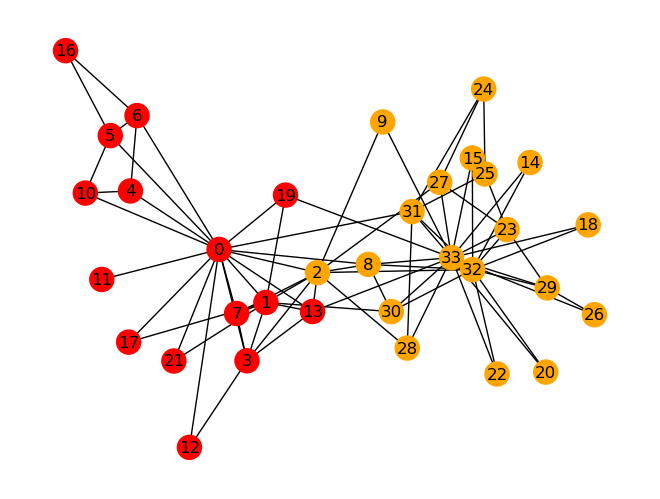

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community.centrality import girvan_newman

G = nx.karate_club_graph()
communities = girvan_newman(G)

node_groups = []
for com in next(communities):
    node_groups.append(list(com))

print(node_groups)

color_map = []
for node in G:
    if node in node_groups[0]:
        color_map.append("red")
    else:
        color_map.append("orange")
nx.draw(G, node_color=color_map, with_labels=True)
plt.show()